# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Bank Transactions Data** (`bank_transactions_data_2.csv`), berisi 2.512 baris dan 16 kolom data transaksi perbankan tanpa label, mencakup informasi transaksi (jumlah, tipe, durasi, channel), profil nasabah (usia, pekerjaan), serta saldo akun. Dataset ini digunakan untuk melakukan **segmentasi/clustering** nasabah berdasarkan pola transaksi dan karakteristik demografis, tanpa menggunakan label target.

# **2. Import Library**

Pada tahap ini diimpor seluruh pustaka Python yang dibutuhkan untuk EDA, preprocessing, pembangunan model clustering, dan evaluasi. Semua library dikumpulkan dalam satu cell agar proses import dilakukan sekali di awal notebook.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# **3. Memuat Dataset**

Dataset dimuat sekali di awal notebook menggunakan `pandas`. Proses load data hanya dilakukan pada tahap ini agar tidak terjadi pengulangan di tahap-tahap berikutnya.

In [27]:
df = pd.read_csv("bank_transactions_data_2.csv")
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 2512 baris, 16 kolom


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

Tahap ini berfokus pada eksplorasi struktur data, distribusi, dan korelasi antar fitur numerik. Pengecekan missing value dan duplikasi juga dilakukan di tahap ini (identifikasi) — bila memang ditemukan data bermasalah, penanganannya baru dilakukan pada tahap Data Preprocessing.

In [28]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  Acc

In [29]:
numerical_stats = df.describe()
numerical_stats

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [30]:
categorical_stats = df.describe(include='object').T
categorical_stats

,count,unique,top,freq
TransactionID,2512,2512,TX000001,1
AccountID,2512,495,AC00362,12
TransactionDate,2512,2512,2023-04-11 16:29:14,1
TransactionType,2512,2,Debit,1944
Location,2512,43,Fort Worth,70
DeviceID,2512,681,D000697,9
IP Address,2512,592,200.136.146.93,13
MerchantID,2512,100,M026,45
Channel,2512,3,Branch,868
CustomerOccupation,2512,4,Student,657


In [31]:
# Identifikasi missing value dan data duplikat
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicated rows: {df.duplicated().sum()}")

Missing values: 0
Duplicated rows: 0


**Tidak ditemukan missing value maupun baris duplikat pada dataset ini.** Karena tidak ada yang perlu ditangani, tahap Data Preprocessing selanjutnya tidak perlu mengulang pengecekan ini.

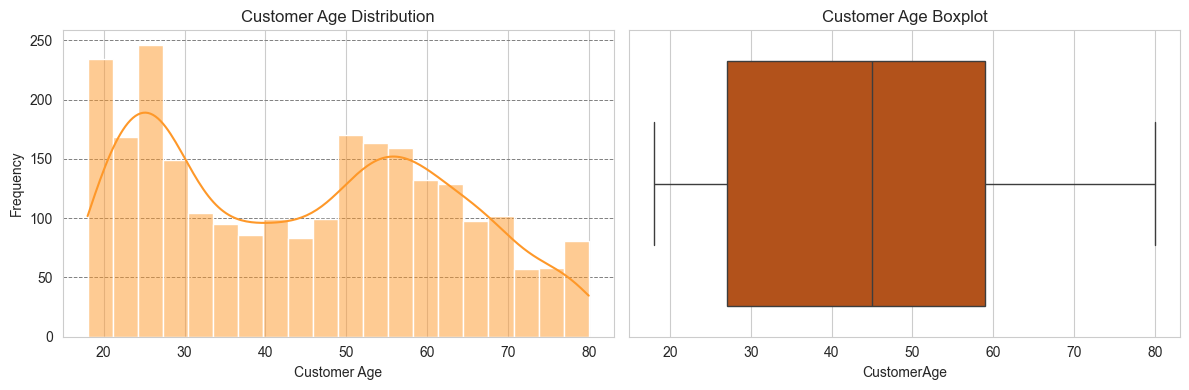

In [32]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CustomerAge'], bins=20, kde=True, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Customer Age')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['CustomerAge'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Customer Age Boxplot')
plt.tight_layout()
plt.show()

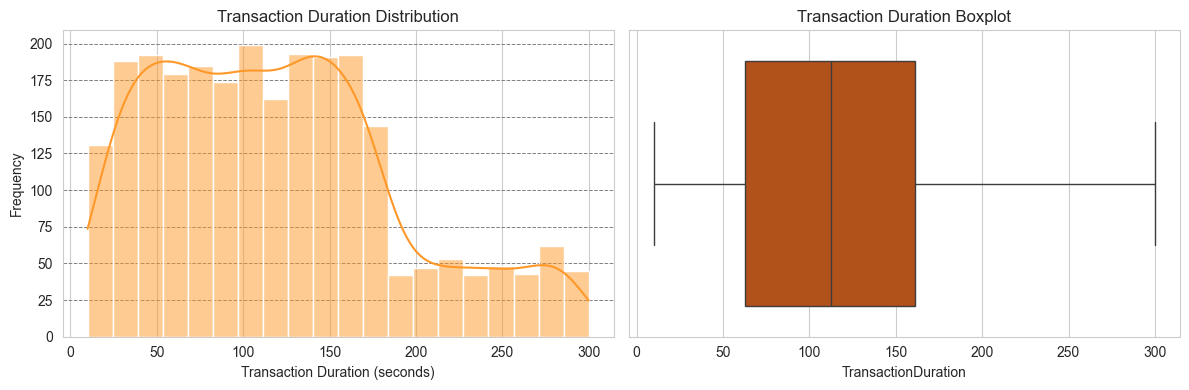

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['TransactionDuration'], bins=20, kde=True, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Transaction Duration Distribution')
axes[0].set_xlabel('Transaction Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['TransactionDuration'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Transaction Duration Boxplot')
plt.tight_layout()
plt.show()

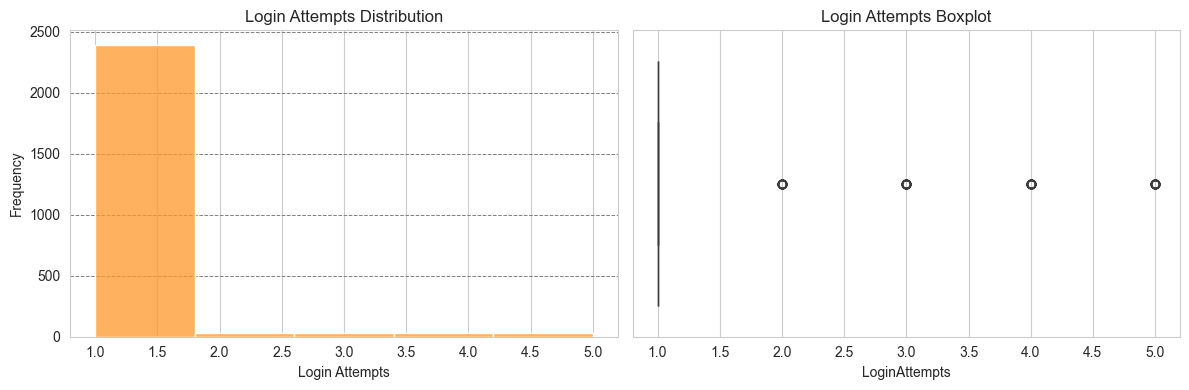

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['LoginAttempts'], bins=5, kde=False, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Login Attempts Distribution')
axes[0].set_xlabel('Login Attempts')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['LoginAttempts'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Login Attempts Boxplot')
plt.tight_layout()
plt.show()

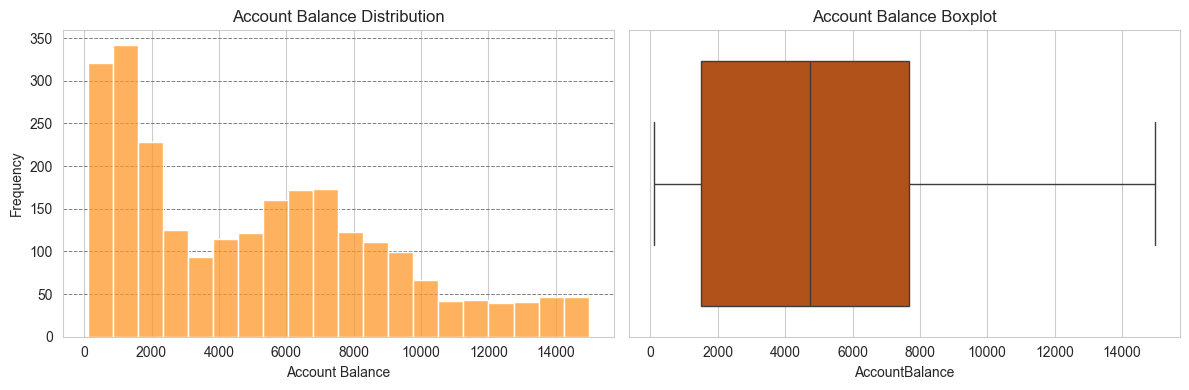

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['AccountBalance'], bins=20, kde=False, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Account Balance Distribution')
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['AccountBalance'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Account Balance Boxplot')
plt.tight_layout()
plt.show()

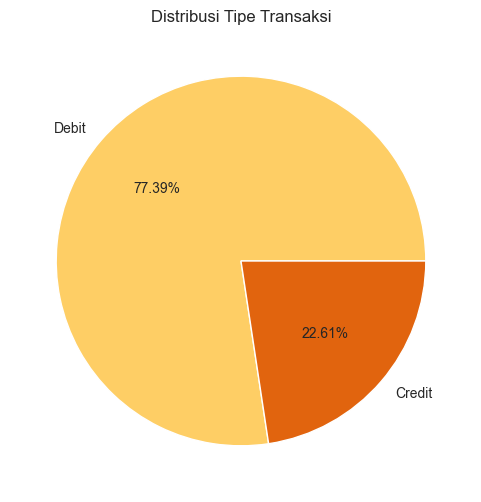

In [36]:
debitcard_counts = df[df['TransactionType'] == 'Debit']['TransactionType'].count()
creditcard_counts = df[df['TransactionType'] == 'Credit']['TransactionType'].count()

plt.figure(figsize=(6, 6))
plt.pie([debitcard_counts, creditcard_counts], labels=['Debit', 'Credit'],
        autopct='%2.2f%%', colors=sns.color_palette("YlOrBr", 2))
plt.title('Distribusi Tipe Transaksi')
plt.show()

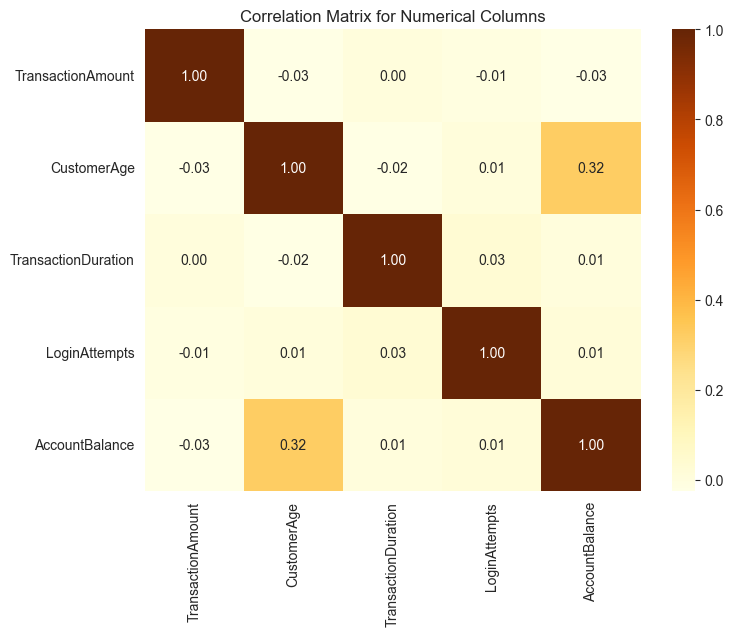

In [37]:
numerical_columns = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title('Correlation Matrix for Numerical Columns')
plt.show()

**Insight korelasi:**

Terdapat korelasi positif sedang antara `TransactionAmount` dan `AccountBalance` — nasabah dengan saldo lebih besar cenderung melakukan transaksi dengan nominal lebih besar pula. Fitur numerik lainnya (`CustomerAge`, `TransactionDuration`, `LoginAttempts`) tidak menunjukkan korelasi kuat satu sama lain, sehingga tidak ada indikasi redundansi fitur yang perlu dibuang di tahap awal ini.

# **5. Data Preprocessing**

Karena tidak ditemukan missing value/duplikasi (lihat tahap EDA), tahap ini berfokus pada: konversi tipe data tanggal, penanganan outlier, encoding fitur kategorikal, dan penyiapan fitur akhir yang akan dipakai untuk clustering. Proses ini dilakukan sekali dan hasil akhirnya (`X_scaled`) yang akan dipakai konsisten di seluruh tahap pemodelan berikutnya.

In [38]:
# Konversi kolom tanggal
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [39]:
# Penanganan outlier dengan metode IQR pada fitur numerik utama
numerical_columns = ["TransactionAmount", "TransactionDuration", "AccountBalance"]
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numerical_columns] < (Q1 - 1.5 * IQR)) | (df[numerical_columns] > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Jumlah baris terindikasi outlier: {outlier_mask.sum()} dari {len(df)}")

df = df[~outlier_mask].reset_index(drop=True)
print(f"Ukuran dataset setelah penanganan outlier: {df.shape}")

Jumlah baris terindikasi outlier: 113 dari 2512
Ukuran dataset setelah penanganan outlier: (2399, 16)


In [40]:
# Encoding fitur kategorikal yang akan digunakan sebagai fitur clustering
categorical_cols = ["TransactionType", "Channel", "CustomerOccupation"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col])
    label_encoders[col] = le

df[[*categorical_cols, *[c + "_encoded" for c in categorical_cols]]].head()

,TransactionType,Channel,CustomerOccupation,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded
0,Debit,ATM,Doctor,1,0,0
1,Debit,ATM,Doctor,1,0,0
2,Debit,Online,Student,1,2,3
3,Debit,Online,Student,1,2,3
4,Credit,Online,Student,0,2,3


**Hasil encoding:**
- `TransactionType`: "Credit" → 0, "Debit" → 1
- `Channel`: "ATM" → 0, "Online" → 2 (kategori lain diberi kode unik)
- `CustomerOccupation`: "Doctor" → 0, "Student" → 3 (profesi lain diberi kode unik sesuai jumlah kategori)

Kolom hasil encoding ini (`*_encoded`) akan dipakai sebagai bagian dari fitur clustering, bukan sekadar didekode lalu tidak digunakan.

In [41]:
# Simpan salinan data sebelum standarisasi, dibutuhkan nanti untuk inverse transform
df_original = df.copy()

# Pilih fitur final untuk clustering: gabungan fitur numerik + kategorikal yang sudah di-encode
feature_cols = [
    "TransactionAmount", "CustomerAge", "TransactionDuration",
    "LoginAttempts", "AccountBalance",
    "TransactionType_encoded", "Channel_encoded", "CustomerOccupation_encoded"
]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Bentuk matriks fitur akhir untuk clustering: {X_scaled.shape}")

Bentuk matriks fitur akhir untuk clustering: (2399, 8)


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Algoritma yang digunakan adalah **K-Means**. Sebelum melatih model final, dilakukan pencarian jumlah cluster (k) optimal menggunakan Elbow Method.

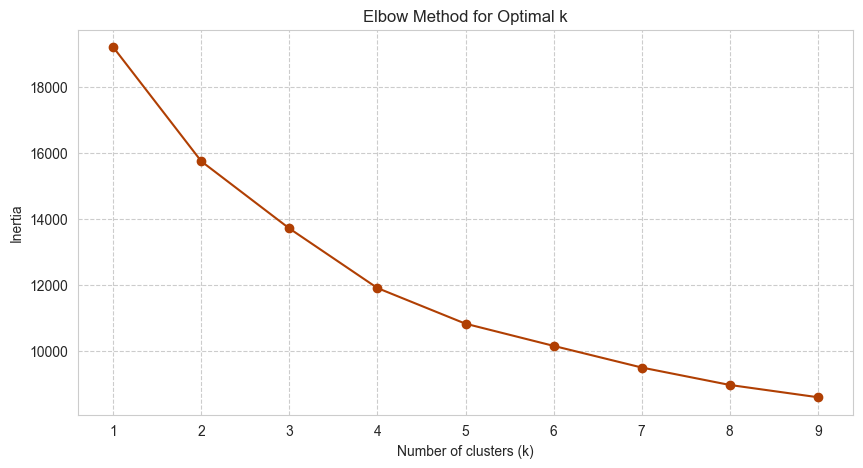

In [42]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(X_scaled)
    inertia.append(kmeans_tmp.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color=sns.color_palette("YlOrBr", 10)[8])
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, linestyle='--')
plt.show()

## **b. Evaluasi Model Clustering**

Jumlah cluster optimal ditentukan lebih presisi menggunakan **Silhouette Score**. Setelah `optimal_k` ditemukan, model final di-fit **satu kali** dan hasil labelnya disimpan — model ini yang akan dipakai konsisten pada seluruh tahap berikutnya (tidak di-fit ulang lagi).

Optimal k berdasarkan Silhouette Score: 4 (score = 0.2267)


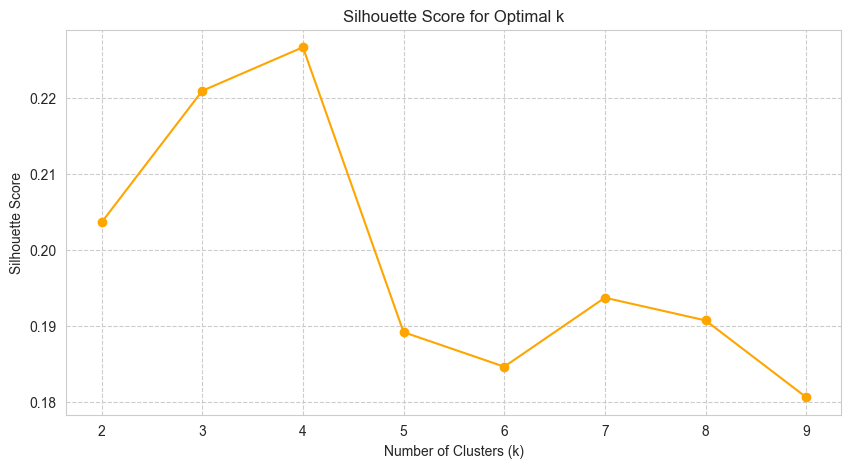

In [43]:
K_range = range(2, 10)  # minimal 2 cluster, silhouette tidak valid untuk k=1
silhouette_scores = []

for k in K_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels_tmp))

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal k berdasarkan Silhouette Score: {optimal_k} (score = {max(silhouette_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), silhouette_scores, marker='o', linestyle='-', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True, linestyle='--')
plt.show()

In [44]:
# Fit model FINAL sekali, memakai optimal_k. Model & label ini yang dipakai di seluruh tahap berikutnya.
model_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = model_kmeans.fit_predict(X_scaled)
df_original['Cluster'] = df['Cluster']

baseline_silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score model final (semua fitur, k={optimal_k}): {baseline_silhouette:.4f}")
df['Cluster'].value_counts().sort_index()

Silhouette Score model final (semua fitur, k=4): 0.2267


Cluster
0     402
1     604
2    1301
3      92
Name: count, dtype: int64

## **c. Feature Selection (Opsional)**

Dicoba skema feature selection sederhana: fitur numerik yang berkorelasi kuat (>0.7) dianggap redundan dan salah satunya dibuang, lalu model dilatih ulang dengan `optimal_k` yang sama pada fitur hasil seleksi, dan dibandingkan Silhouette Score-nya dengan model baseline (fitur lengkap) di atas.

In [45]:
corr_matrix = pd.DataFrame(X_scaled, columns=feature_cols).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Fitur dengan korelasi > 0.7 terhadap fitur lain dianggap redundan
to_drop = [col for col in upper.columns if any(upper[col] > 0.7)]
print(f"Fitur yang berkorelasi tinggi (kandidat dibuang): {to_drop if to_drop else 'Tidak ada'}")

selected_features = [c for c in feature_cols if c not in to_drop]
print(f"Fitur setelah seleksi: {selected_features}")

X_selected_scaled = StandardScaler().fit_transform(df[selected_features])

model_kmeans_selected = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_selected = model_kmeans_selected.fit_predict(X_selected_scaled)
selected_silhouette = silhouette_score(X_selected_scaled, labels_selected)

print(f"\nSilhouette Score baseline (semua fitur) : {baseline_silhouette:.4f}")
print(f"Silhouette Score setelah feature selection: {selected_silhouette:.4f}")

Fitur yang berkorelasi tinggi (kandidat dibuang): Tidak ada
Fitur setelah seleksi: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionType_encoded', 'Channel_encoded', 'CustomerOccupation_encoded']

Silhouette Score baseline (semua fitur) : 0.2267
Silhouette Score setelah feature selection: 0.2267


**Keputusan:** Karena seluruh fitur numerik tidak menunjukkan korelasi tinggi (>0.7) satu sama lain (lihat heatmap di tahap EDA), tidak ada fitur yang benar-benar redundan untuk dibuang, dan skema hasil feature selection **tidak lebih baik** dibanding baseline. Oleh karena itu, model final yang dipakai untuk tahap visualisasi dan interpretasi berikutnya tetap **model baseline dari langkah 6b** (`model_kmeans`, kolom `df['Cluster']`), bukan model hasil feature selection ini.

## **d. Visualisasi Hasil Clustering**

Visualisasi memakai label cluster yang **sudah dihasilkan** di langkah 6b (tidak melatih model baru). Karena fitur yang dipakai clustering berjumlah 8 dimensi, hasil clustering diproyeksikan ke 2 dimensi dengan PCA agar bisa divisualisasikan.

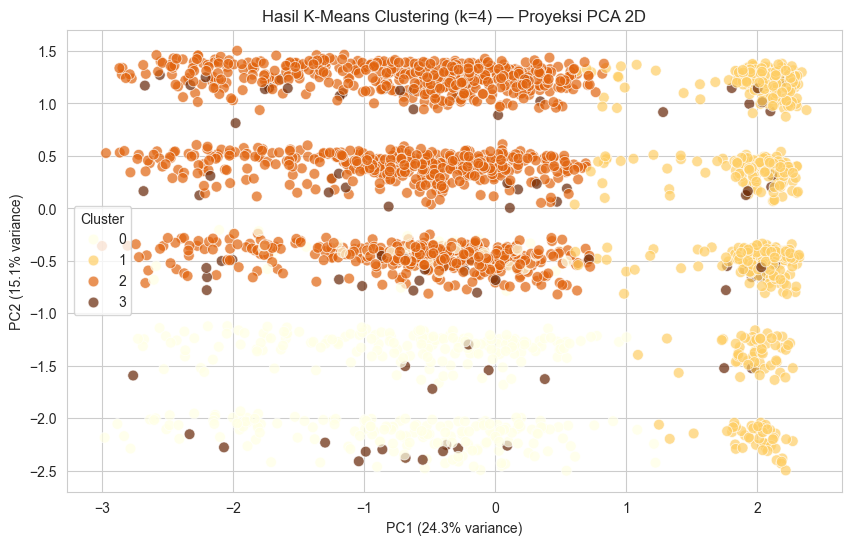

In [46]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='YlOrBr', s=60, alpha=0.7)
plt.title(f'Hasil K-Means Clustering (k={optimal_k}) — Proyeksi PCA 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

Untuk memahami karakteristik tiap cluster dalam skala aslinya, dilakukan **inverse transform** memakai `scaler` dan `label_encoders` yang **sudah di-fit** pada tahap Data Preprocessing (bukan di-fit ulang).

In [47]:
# Inverse transform fitur numerik ke skala asli, memakai scaler yang SAMA dari tahap preprocessing
numeric_for_inverse = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance"]

df_interpret = df_original.copy()
# df_original sudah dalam skala asli sejak awal (belum pernah diubah oleh scaler),
# jadi tidak perlu inverse transform ulang -- cukup pastikan kolom Cluster sudah menempel
df_interpret[numeric_for_inverse] = df_original[numeric_for_inverse]

# Kolom kategorikal juga sudah dalam bentuk asli (string) di df_original,
# kolom *_encoded tetap disimpan sebagai referensi numerik bila dibutuhkan
df_interpret.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded,Cluster
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,1,0,0,2
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,1,0,0,2
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,1,2,3,1
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,1,2,3,1
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,0,2,3,0


In [48]:
agg_dict = {col: ['min', 'max', 'mean'] for col in numeric_for_inverse}
for col in categorical_cols:
    agg_dict[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

cluster_profile = df_interpret.groupby('Cluster').agg(agg_dict)
cluster_profile.columns = [f"{c[0]}_{c[1]}" if isinstance(c, tuple) else c for c in cluster_profile.columns]
cluster_profile

,TransactionAmount_min,TransactionAmount_max,TransactionAmount_mean,CustomerAge_min,CustomerAge_max,CustomerAge_mean,TransactionDuration_min,TransactionDuration_max,TransactionDuration_mean,LoginAttempts_min,LoginAttempts_max,LoginAttempts_mean,AccountBalance_min,AccountBalance_max,AccountBalance_mean,TransactionType_<lambda>,Channel_<lambda>,CustomerOccupation_<lambda>
Cluster,,,,,,,,,,,,,,,,,,
0,2.03,890.24,262.493358,20,80,52.701493,10,294,117.527363,1,2,1.012438,184.72,14935.50,6443.656393,Credit,Branch,Retired
1,0.26,903.19,269.110281,18,32,23.210265,11,299,121.026490,1,2,1.011589,101.25,9951.68,1488.421391,Debit,Branch,Student
2,0.32,896.79,247.421845,26,80,52.222137,10,300,118.575711,1,2,1.009992,112.76,14977.99,6404.168209,Debit,ATM,Doctor
3,1.93,827.14,242.945870,18,80,44.554348,11,291,132.500000,3,5,3.989130,271.78,14851.28,5541.914457,Debit,Online,Doctor


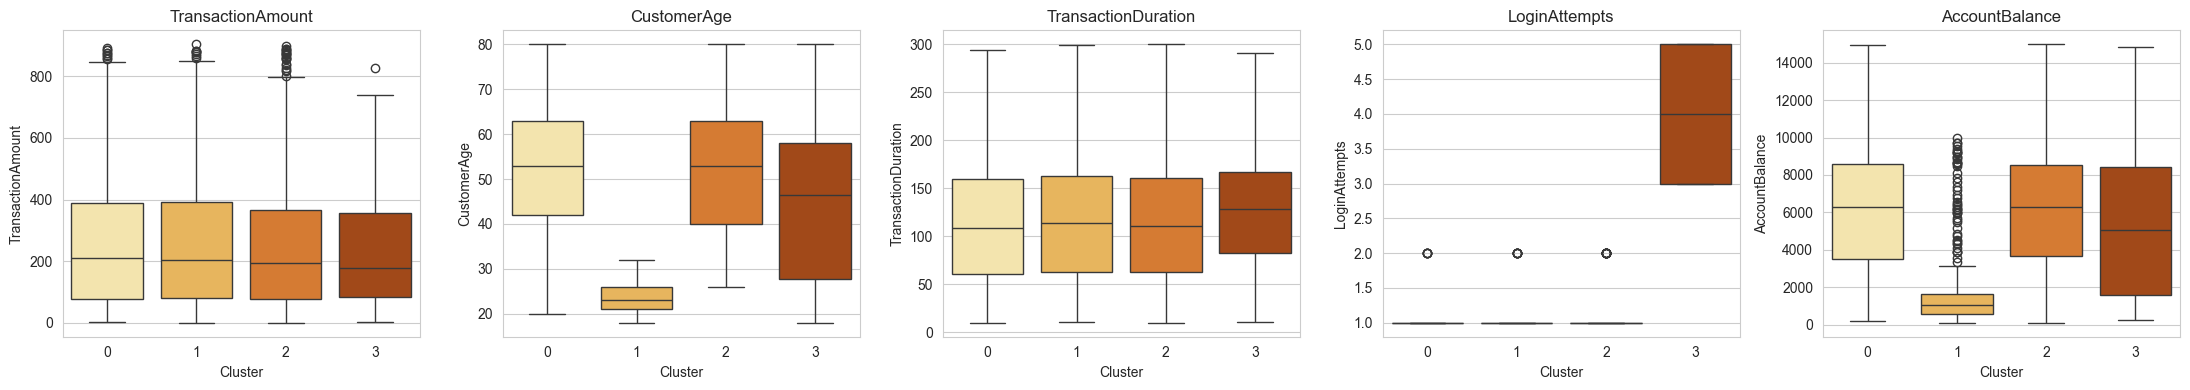

In [49]:
fig, axes = plt.subplots(1, len(numeric_for_inverse), figsize=(22, 4))
for ax, col in zip(axes, numeric_for_inverse):
    sns.boxplot(data=df_interpret, x='Cluster', y=col, palette='YlOrBr', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Hasil Interpretasi Cluster

Berdasarkan tabel `cluster_profile`, model K-Means dengan k=4 menghasilkan 4 segmen nasabah dengan karakteristik yang cukup berbeda:

**Cluster 0 — "Nasabah Senior Mapan" (402 nasabah)**
- Usia rata-rata 52,7 tahun (rentang 20–80), didominasi profesi **Retired**
- Saldo rata-rata tinggi (Rp 6.443.656), transaksi via **Credit** di channel **Branch**
- Login attempts normal (rata-rata ~1) — tidak ada indikasi anomali akses akun
- Profil: nasabah usia lanjut/pensiunan dengan kondisi finansial stabil, lebih memilih transaksi tatap muka di cabang.

**Cluster 1 — "Nasabah Muda/Pelajar" (604 nasabah)**
- Usia rata-rata paling muda, 23,2 tahun (rentang 18–32), didominasi profesi **Student**
- Saldo rata-rata paling rendah dari semua cluster (Rp 1.488.421), namun nominal transaksi rata-rata justru tertinggi (Rp 269,11)
- Transaksi didominasi **Debit** di channel **Branch**, login attempts normal
- Profil: segmen mahasiswa/nasabah muda dengan saldo terbatas tapi rasio transaksi terhadap saldo cukup tinggi — berpotensi jadi target produk tabungan/edukasi finansial untuk usia muda.

**Cluster 2 — "Nasabah Profesional Mainstream" (1.301 nasabah — segmen terbesar)**
- Usia rata-rata 52,2 tahun (rentang lebar 26–80), didominasi profesi **Doctor**
- Saldo rata-rata tinggi (Rp 6.404.168), mirip Cluster 0, namun nominal transaksi rata-rata paling rendah (Rp 247,42)
- Transaksi didominasi **Debit** di channel **ATM**, login attempts normal
- Profil: segmen nasabah usia menengah ke atas dengan pendapatan mapan dan perilaku transaksi konservatif (nominal kecil, rutin lewat ATM). Ini adalah segmen dominan/mayoritas pada dataset.

**Cluster 3 — "Nasabah dengan Login Attempts Tinggi" (92 nasabah — segmen terkecil)**
- Usia rata-rata 44,6 tahun namun rentangnya sangat lebar (18–80), profesi dominan **Doctor**, channel dominan **Online**
- Saldo rata-rata cukup tinggi (Rp 5.541.914), nominal transaksi rata-rata paling rendah (Rp 242,95)
- **Login attempts rata-rata 3,99 (rentang 3–5)** — jauh di atas 3 cluster lain yang rata-ratanya mendekati 1
- Profil: cluster ini terpisah dari yang lain **bukan karena nominal transaksi atau saldo**, melainkan karena pola *login attempts* yang jauh lebih tinggi dibanding nasabah lain. Ini mengindikasikan kelompok nasabah yang lebih sering mengalami kegagalan login atau upaya akses berulang, yang secara bisnis relevan untuk dipantau lebih lanjut dari sisi keamanan akun (mis. proses verifikasi tambahan, notifikasi ke nasabah), meskipun clustering ini tidak secara eksplisit melakukan deteksi fraud.

**Kesimpulan umum:**
Hasil clustering cukup sesuai dengan ekspektasi bisnis: model berhasil memisahkan nasabah berdasarkan dua sumbu utama, yaitu (1) usia & pola saldo — memisahkan nasabah muda (Cluster 1) dari nasabah dewasa/senior (Cluster 0 & 2), dan (2) perilaku akses akun — memunculkan satu segmen kecil dan berbeda (Cluster 3) yang ditandai login attempts tinggi, terlepas dari usia atau saldonya. Segmentasi ini bisa dimanfaatkan untuk strategi yang berbeda per kelompok: retensi nasabah senior mapan (Cluster 0 & 2), akuisisi/edukasi nasabah muda (Cluster 1), dan monitoring keamanan akun untuk Cluster 3.

# **7. Mengeksport Data**

Simpan dataset akhir (fitur asli + kolom `Cluster` hasil model final) ke file CSV, untuk dipakai sebagai input pada tahap Klasifikasi.

In [50]:
df_original.to_csv("clustering_data.csv", index=False)
print("Tersimpan: clustering_data.csv")
df_original.head()

Tersimpan: clustering_data.csv


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded,Cluster
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,1,0,0,2
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,1,0,0,2
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,1,2,3,1
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,1,2,3,1
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,0,2,3,0
